In [1]:
%matplotlib widget

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [4]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]

In [29]:
image_error_cut

array([[0.0303987 , 0.02912354, 0.02480921, ..., 0.0067154 , 0.00691563,
        0.00693766],
       [0.03006888, 0.02813161, 0.02885036, ..., 0.00677515, 0.0061732 ,
        0.00663774],
       [0.03166641, 0.02917927, 0.03076373, ..., 0.00689471, 0.00661363,
        0.00693721],
       ...,
       [0.02708479, 0.02681352, 0.03034172, ..., 0.00661501, 0.00649011,
        0.00683801],
       [0.02696249, 0.02753854, 0.02932177, ..., 0.00645496, 0.00637915,
        0.00649103],
       [0.02817379, 0.02815345, 0.02910345, ..., 0.00675251, 0.00685232,
        0.00682028]], dtype='>f4')

Text(0.5, 0, 'wavelenght')

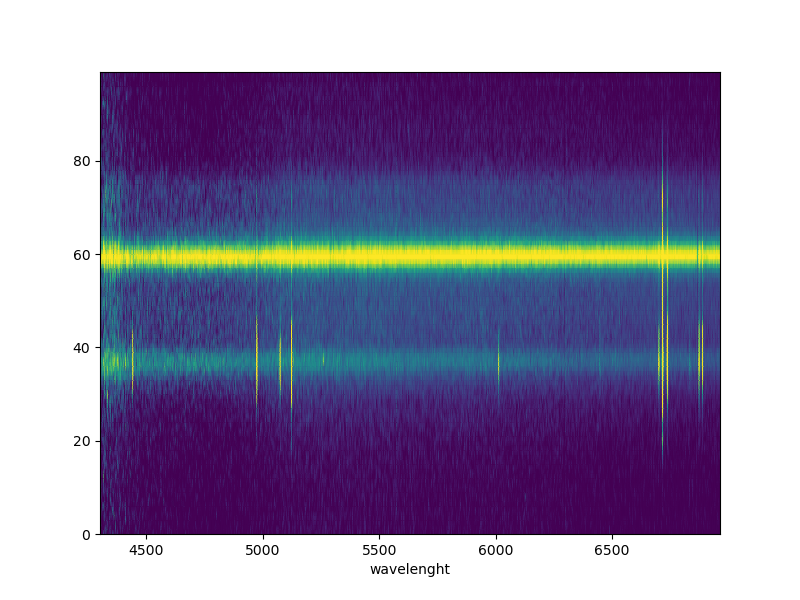

In [5]:
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.figure(figsize=(8,6))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

## Redshift or the lines in air

In [7]:
z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [8]:
l_HA

6719.1994

## Continuum

Text(0.5, 1.0, 'Continuum 3')

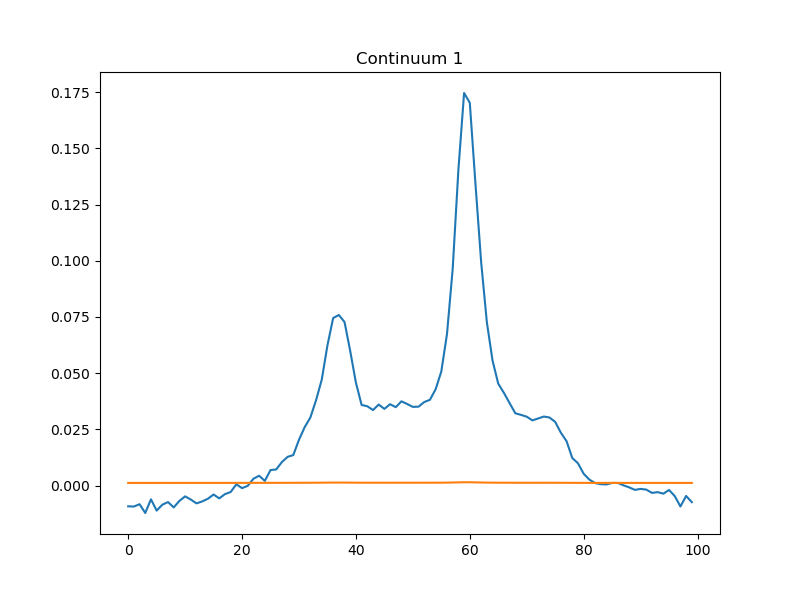

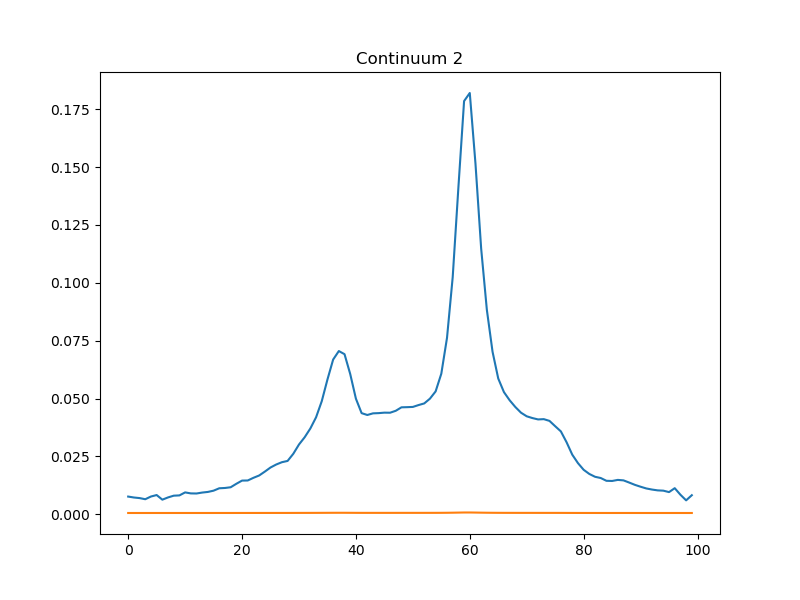

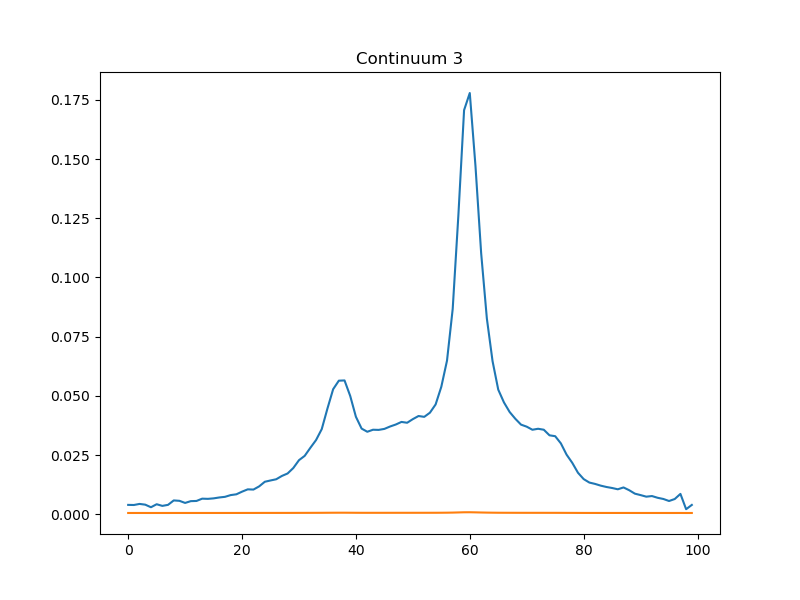

In [33]:
mask_continuum_1 = (wavelenghts > 4500)*(wavelenghts < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
#radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))/image_error_continuum_1.shape[1]
weights_continuum_1 = 1/image_error_continuum_1**2
radial_profile_continuum_1, sum_weights_c1 = np.average(image_continuum_1, axis = 1, weights = weights_continuum_1, returned = True)
radial_profile_error_continuum_1 = 1/np.sqrt(sum_weights_c1)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

mask_continuum_2 = (wavelenghts > 5300)*(wavelenghts < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
#radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))/image_error_continuum_2.shape[1]
weights_continuum_2 = 1/image_error_continuum_2**2
radial_profile_continuum_2, sum_weights_c2 = np.average(image_continuum_2, axis = 1, weights = weights_continuum_2, returned = True)
radial_profile_error_continuum_2 = 1/np.sqrt(sum_weights_c2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

mask_continuum_3 = (wavelenghts > 6400)*(wavelenghts < 6700)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
#radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))/image_error_continuum_3.shape[1]
weights_continuum_3 = 1/image_error_continuum_3**2
radial_profile_continuum_3, sum_weights_c3 = np.average(image_continuum_3, axis = 1, weights = weights_continuum_3, returned = True)
radial_profile_error_continuum_3 = 1/np.sqrt(sum_weights_c3)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

## Sky lines

In [34]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[55:155, 0:1800]

x_grid, y_grid = np.meshgrid(wavelenghts, y)
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelenght')

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


Text(0.5, 36.72222222222221, 'wavelenght')

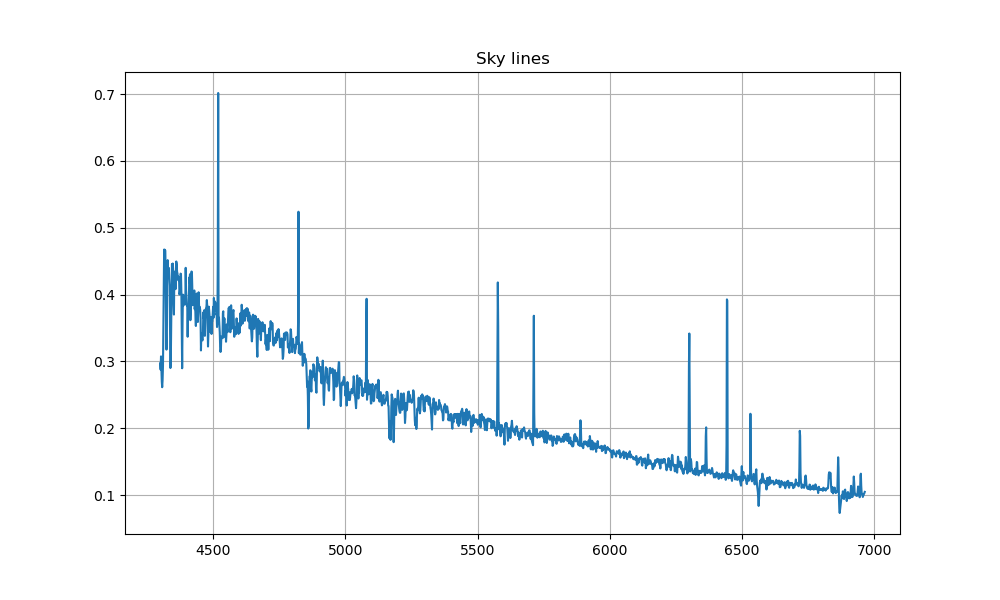

In [35]:
mask_sky = (y > 15)*(y < 25)
image_sky = image_cut2[mask_sky, :]
radial_profile_sky = np.mean(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wavelenghts, radial_profile_sky)
#x_interval = np.arange(4300, 4300+1800*1.48, 250)
#plt.xticks(x_interval)
plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

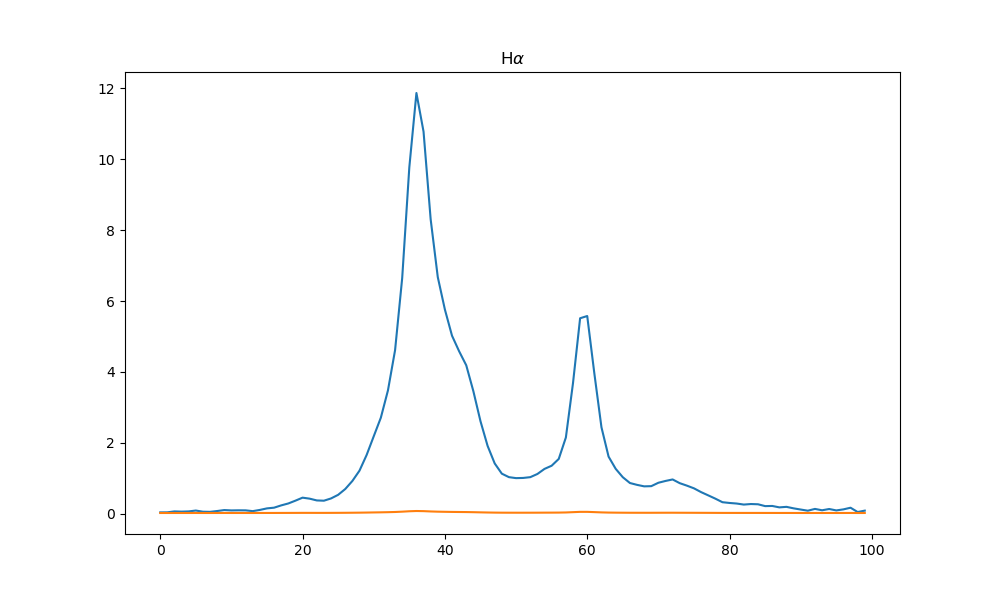

In [36]:
#Ogni punto del flusso è il risultato della media di 20 lunghezze d'onda pesate
mask_HA = (wavelenghts > l_HA-10)*(wavelenghts < l_HA+10)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
weights_HA = 1/image_error_HA**2
radial_profile_HA = np.sum(image_HA, axis = 1)

radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [37]:
np.sum(image_HA[36]*weights_HA[36])/np.sum(weights_HA[36])

0.14182644

In [38]:
weights_HA.shape

(100, 13)

In [39]:
np.sqrt(np.sum(image_error_HA[0]**2))/len(image_error_HA[0])
image_error_HA.shape[1]

13

In [40]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (20, 40),   # x_0: posizione da 0 a 100

    (0, 10),
    (0, 50),
    (0.1, 10),
    (40, 50),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (50, 70),

    (0, 10),
    (0, 50),
    (0.1, 10),
    (70, 80)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 5938.021503458881
differential_evolution step 2: f(x)= 5938.021503458881
differential_evolution step 3: f(x)= 5938.021503458881
differential_evolution step 4: f(x)= 5938.021503458881
differential_evolution step 5: f(x)= 5938.021503458881
differential_evolution step 6: f(x)= 5938.021503458881
differential_evolution step 7: f(x)= 5938.021503458881
differential_evolution step 8: f(x)= 890.2130034330867
differential_evolution step 9: f(x)= 806.7766889542056
differential_evolution step 10: f(x)= 806.7766889542056
differential_evolution step 11: f(x)= 632.1729320809612
differential_evolution step 12: f(x)= 632.1729320809612
differential_evolution step 13: f(x)= 632.1729320809612
differential_evolution step 14: f(x)= 632.1729320809612
differential_evolution step 15: f(x)= 433.919689801844
differential_evolution step 16: f(x)= 433.919689801844
differential_evolution step 17: f(x)= 433.919689801844
differential_evolution step 18: f(x)= 264.74870145569145
dif

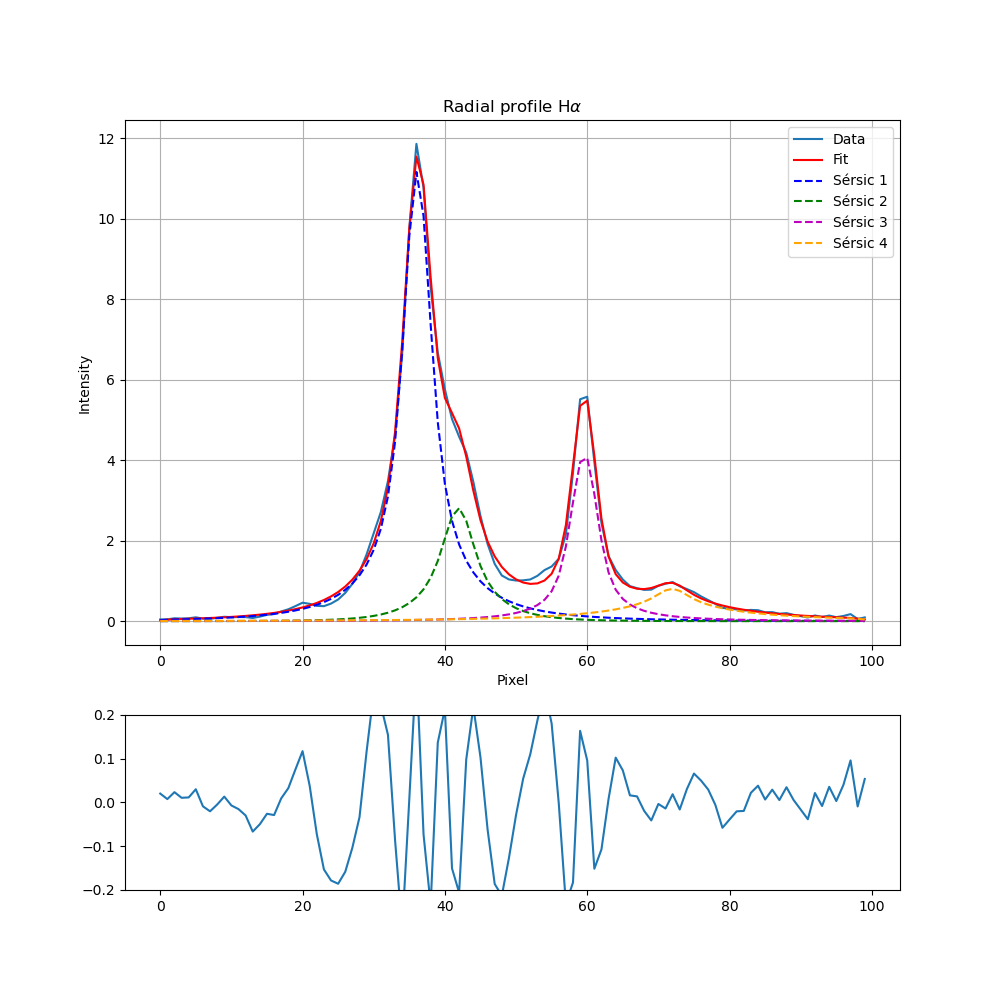

In [41]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].set_ylim(0, 0.3)
#ax[0].tight_layout()

ax[1].plot(x_axes, radial_profile_HA - y_fit)
ax[1].set_ylim(-0.2, 0.2)

plt.savefig('Radial_profile_Halpha_diff_sum')

In [42]:
params_curve_HA, covariance_HA = curve_fit(model_convolved, x_axes, radial_profile_HA, p0=result.x, sigma = radial_profile_error_HA)

print("Optimize parameters with curve fit:")

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0_HA = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0_HA[i] = params_curve_HA[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HA)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HA)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0_HA[i]:.4f}")

print(np.sqrt(np.diag(covariance_HA)))
#print(infodict.fvec**2)
chi2_HA = np.sum((((radial_profile_HA - model_convolved(x_axes, *params_curve_HA)) / radial_profile_error_HA)**2))
dof_HA = len(radial_profile_HA) - len(params_curve_HA)
chi2_reduced_HA = chi2_HA / dof_HA
print(chi2_reduced_HA)

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0_HA, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Halpha_fit_sum.csv", index= False, float_format='%.4f')

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16812\2970919958.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16812\2970919958.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


Optimize parameters with curve fit:
Sérsic 1: I_e=0.6563, r_e=10.9053, n=2.1071, x_0=36.1541
Sérsic 2: I_e=0.4425, r_e=6.3146, n=1.3466, x_0=41.9346
Sérsic 3: I_e=0.1499, r_e=11.5031, n=2.9436, x_0=59.5634
Sérsic 4: I_e=0.0638, r_e=26.7978, n=1.5741, x_0=72.0963
[1.37686028e-01 1.47029462e+00 1.61447752e-01 4.75878455e-02
 2.72052544e-01 3.48653913e+00 4.39441596e-01 1.81209653e-01
 7.64925199e-01 3.94954243e+01 5.64756201e+00 2.45183542e-03
 4.56752825e-02 1.54340621e+01 4.32894141e-01 4.73091086e-01]
8.259406377091043


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_16812\1221597103.py:5: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])


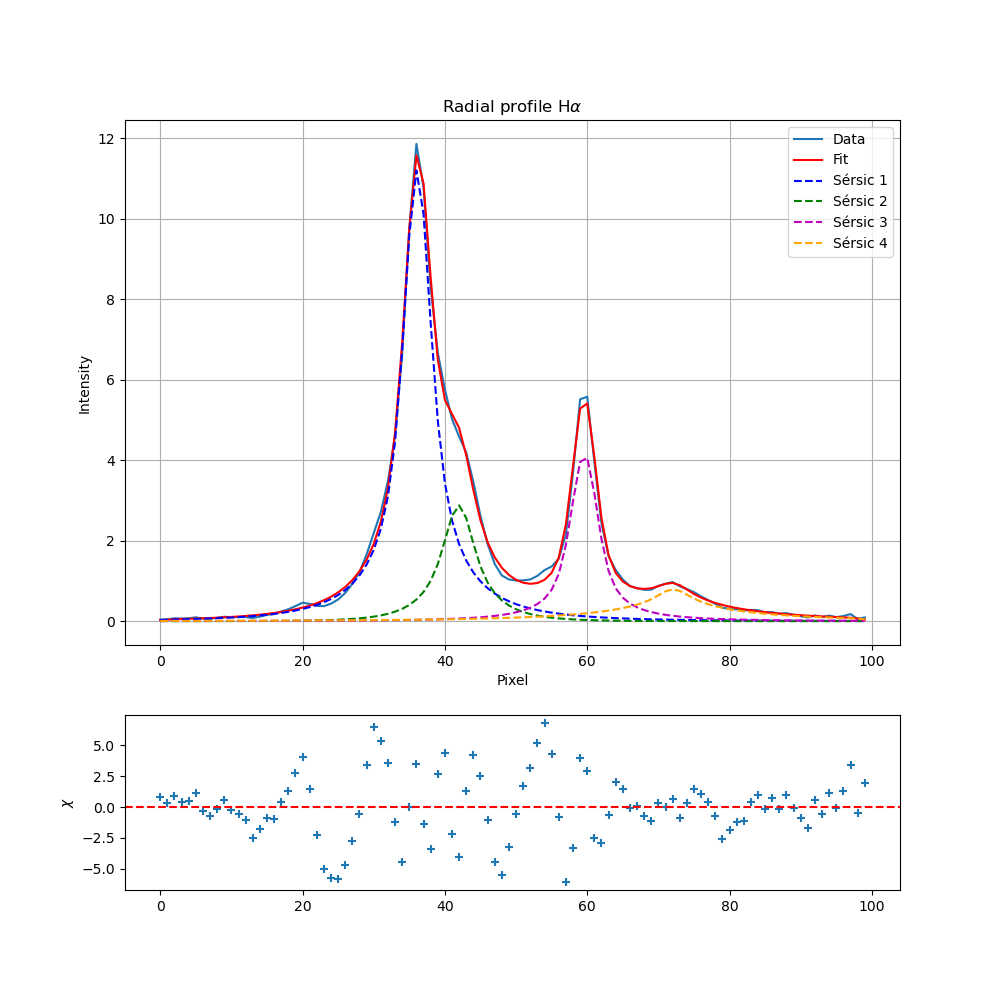

In [43]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HA)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

ax[0].plot(x_axes, radial_profile_HA, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HA[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\alpha$")
ax[0].legend()
ax[0].grid(True)
#ax[0].set_ylim(0, 0.3)
#ax[0].tight_layout()

ax[1].scatter(x_axes, (radial_profile_HA - y_fit)/radial_profile_error_HA, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')

plt.savefig('Radial_profile_Halpha_curve_sum')

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

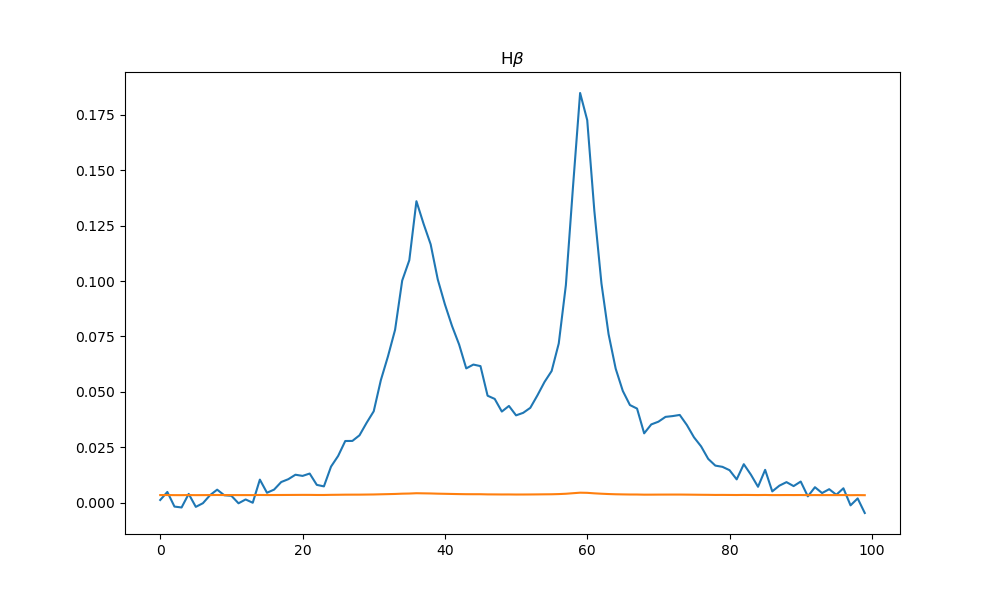

In [32]:
mask_HB = (wavelenghts > l_HB-10)*(wavelenghts < l_HB+10)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
weights_HB = 1/image_error_HB**2
radial_profile_HB, sum_weights_HB = np.average(image_HB, axis = 1, weights = weights_HB, returned = True)
radial_profile_error_HB = 1/np.sqrt(sum_weights_HB)
#radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))/image_error_HB.shape[1]

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

Text(0.5, 1.0, 'H$\\beta$')

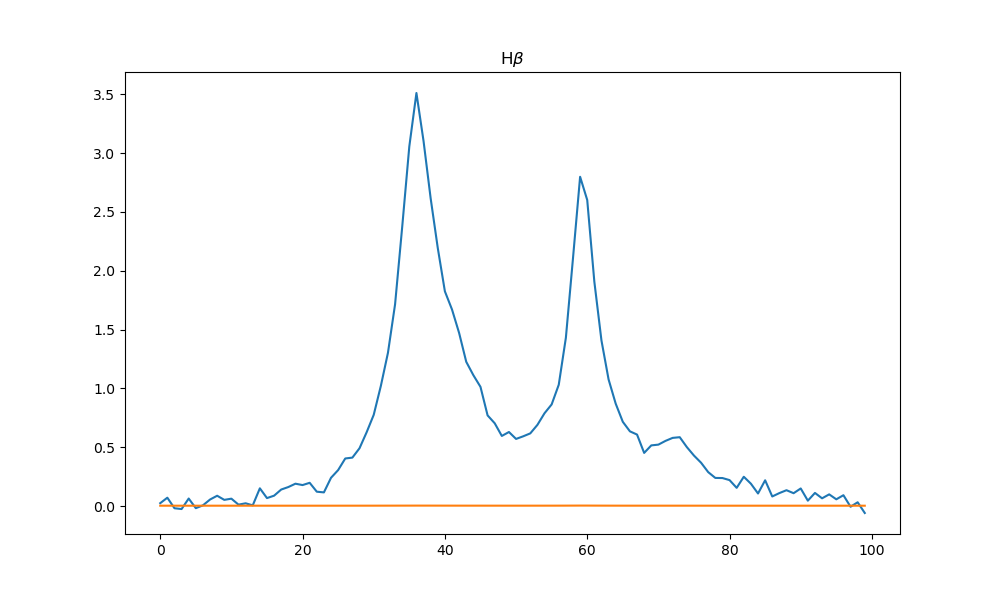

In [34]:
mask_HB = (wavelenghts > l_HB-10)*(wavelenghts < l_HB+10)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
weights_HB = 1/image_error_HB**2
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = 1/np.sqrt(sum_weights_HB)
#radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))/image_error_HB.shape[1]

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [23]:
print(weights_HB[20])
print(np.mean(weights_HB[20]))
print(weights_HB[39])
print(np.mean(weights_HB[39]))
print(weights_HB[60])
print(np.mean(weights_HB[60]))
print(weights_HB[80])
print(np.mean(weights_HB[80]))

[5444.368  5320.4707 5312.678  5289.4785 5031.9614 5272.2573 5212.559
 4791.512  5577.304  5455.771  5994.322  6375.2085 6336.6133 5773.4004]
5513.4214
[4462.59   4464.206  4908.089  4911.4927 4636.73   3229.2178 1704.8271
 1585.7076 3076.4666 4788.941  5330.8516 5260.6587 5118.3413 4825.734 ]
4164.561
[3466.3413 3482.7495 3723.337  3761.0613 3502.8704 3303.4624 2589.7925
 2166.0847 2881.9285 3818.1687 4234.328  4131.633  4066.417  3827.8394]
3496.8582
[5693.164  5488.8765 5345.069  5381.8833 5719.2334 5057.943  4899.741
 5239.776  5283.8794 5832.563  5937.2607 6724.8755 6618.771  5603.782 ]
5630.4873


In [24]:
print(image_error_HB[20])
print(np.mean(image_error_HB[20]))
print(image_error_HB[39])
print(np.mean(image_error_HB[39]))
print(image_error_HB[60])
print(np.mean(image_error_HB[60]))
print(image_error_HB[80])
print(np.mean(image_error_HB[80]))

[0.01355271 0.01370961 0.01371966 0.01374971 0.01409715 0.01377215
 0.01385079 0.01444654 0.01339022 0.01353854 0.01291606 0.01252428
 0.01256236 0.01316086]
0.01349933
[0.01496947 0.01496676 0.01427394 0.01426899 0.01468568 0.01759752
 0.0242192  0.02511241 0.01802909 0.01445041 0.01369625 0.01378732
 0.01397769 0.01439522]
0.016316427
[0.01698495 0.01694489 0.0163883  0.0163059  0.01689616 0.01739864
 0.01965022 0.02148633 0.01862766 0.0161835  0.01536766 0.01555748
 0.01568173 0.01616304]
0.01711689
[0.01325327 0.01349765 0.01367802 0.01363116 0.01322303 0.0140609
 0.01428609 0.01381477 0.01375699 0.01309394 0.01297798 0.01219433
 0.01229168 0.01335855]
0.0133655965


In [25]:
print(image_HB[20])
print(np.mean(image_HB[20]))
print(image_HB[39])
print(np.mean(image_HB[39]))
print(image_HB[60])
print(np.mean(image_HB[60]))
print(image_HB[80])
print(np.mean(image_HB[80]))

[ 0.00568218  0.01457902  0.0149163   0.0106461   0.01717658  0.00738867
  0.01447491  0.04758856  0.01047383  0.01765705  0.01400733  0.00293079
 -0.00040879  0.00176306]
0.012776827
[0.06459174 0.06800298 0.03964349 0.03525473 0.04322763 0.18776044
 0.5955069  0.6691901  0.22681485 0.06136227 0.04021003 0.05948371
 0.05102099 0.05135277]
0.15667306
[0.17292131 0.1671022  0.13610609 0.12667766 0.15269047 0.17912954
 0.3146361  0.42698395 0.26103657 0.14824143 0.11918387 0.13485694
 0.12979816 0.1322991 ]
0.18583311
[ 0.00183578  0.02030003  0.02127209  0.01493771 -0.01309215  0.02980103
  0.03965034  0.03246852  0.0336086   0.00968182  0.02327815 -0.00341355
 -0.00438093  0.01502169]
0.015783507


In [108]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 5.135081956790113
differential_evolution step 2: f(x)= 0.46686649496743726
differential_evolution step 3: f(x)= 0.1109522394876334
differential_evolution step 4: f(x)= 0.1109522394876334
differential_evolution step 5: f(x)= 0.1109522394876334
differential_evolution step 6: f(x)= 0.05859083480120908
differential_evolution step 7: f(x)= 0.05859083480120908
differential_evolution step 8: f(x)= 0.05859083480120908
differential_evolution step 9: f(x)= 0.025716554659310848
differential_evolution step 10: f(x)= 0.025716554659310848
differential_evolution step 11: f(x)= 0.025716554659310848
differential_evolution step 12: f(x)= 0.02126922016105494
differential_evolution step 13: f(x)= 0.02126922016105494
differential_evolution step 14: f(x)= 0.02126922016105494
differential_evolution step 15: f(x)= 0.019366417308635177
differential_evolution step 16: f(x)= 0.019366417308635177
differential_evolution step 17: f(x)= 0.019366417308635177
differential_evolution

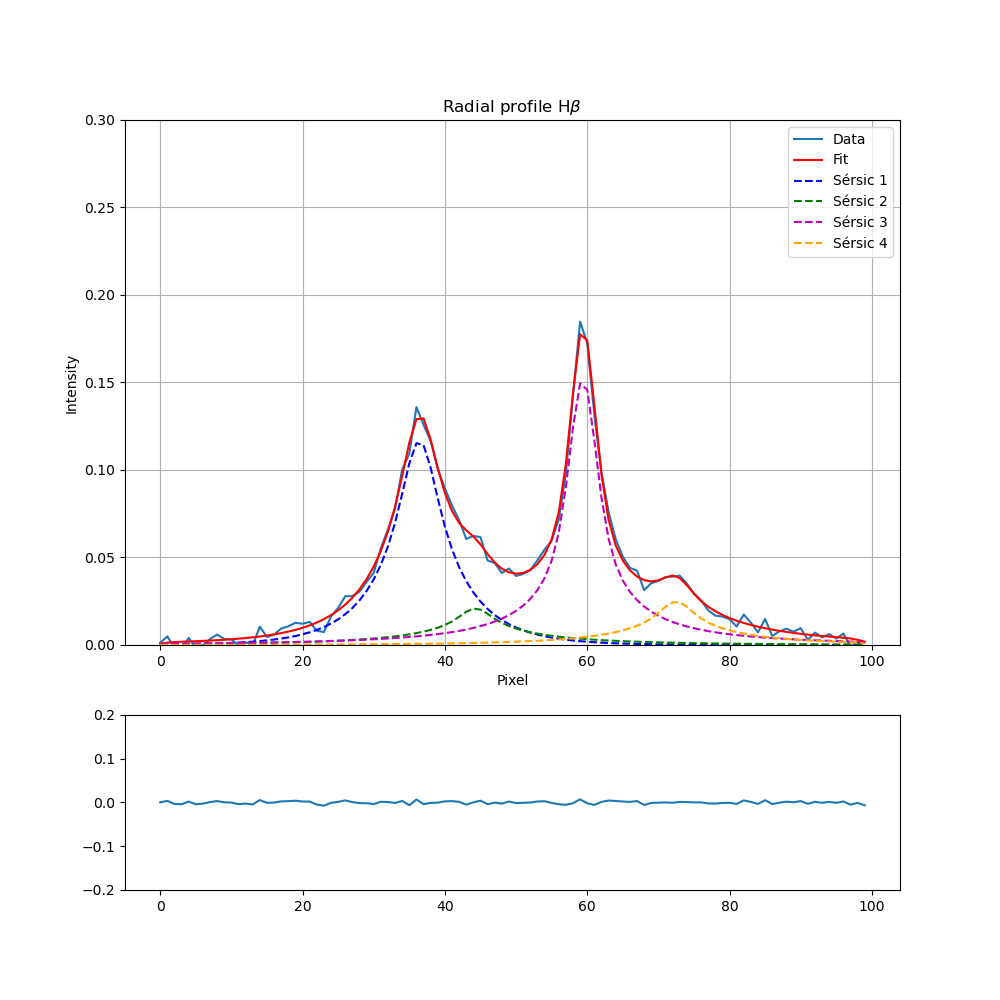

In [109]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,0.3)

ax[1].plot(x_axes, radial_profile_HB - y_fit)
ax[1].set_ylim(-0.2, 0.2)
plt.savefig('Radial_profile_Hbeta_kernel')

In [110]:
params_curve_HB, covariance_HB = curve_fit(model_convolved, x_axes, radial_profile_HB, p0=result.x, sigma = radial_profile_error_HB)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_HB[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_HB)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_HB)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("HBeta_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_HB)))
#print(infodict.fvec**2)
chi2_HB = np.sum((((radial_profile_HB - model_convolved(x_axes, *params_curve_HB)) / radial_profile_error_HB)**2))
dof_HB = len(radial_profile_HB) - len(params_curve_HB)
chi2_reduced_HB = chi2_HB / dof_HB
print(chi2_reduced_HB)

Sérsic 1: I_e=0.0211, r_e=9.3487, n=1.1622, x_0=36.4451
Sérsic 2: I_e=0.0015, r_e=22.5687, n=1.6495, x_0=44.2172
Sérsic 3: I_e=0.0032, r_e=30.4984, n=2.8612, x_0=59.4149
Sérsic 4: I_e=0.0020, r_e=21.2127, n=1.6596, x_0=72.5611
[4.38801654e-03 2.35525083e+00 1.51407990e-01 1.13220409e-01
 4.19398157e-03 1.10132422e+02 1.89276155e+00 7.12272485e-01
 1.65772296e-02 1.35573610e+02 4.06227244e+00 3.10572905e-03
 2.89447120e-03 5.09588159e+01 1.03882393e+00 4.41979412e-01]
0.7973857170146103


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10296\4061730068.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_10296\4061730068.py:22: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')


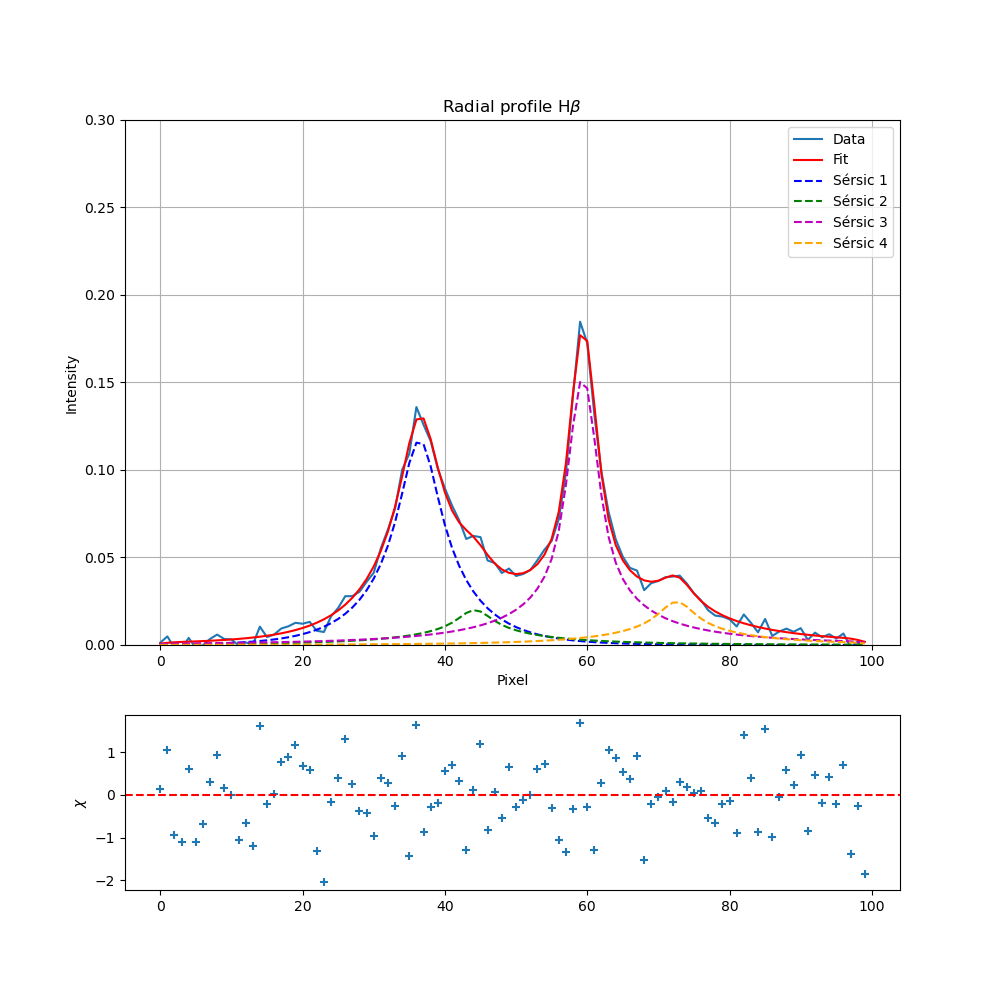

In [111]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_HB)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_HB, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_HB[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title(r"Radial profile H$\beta$")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 0.3)

ax[1].scatter(x_axes, (radial_profile_HB - y_fit)/radial_profile_error_HB, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

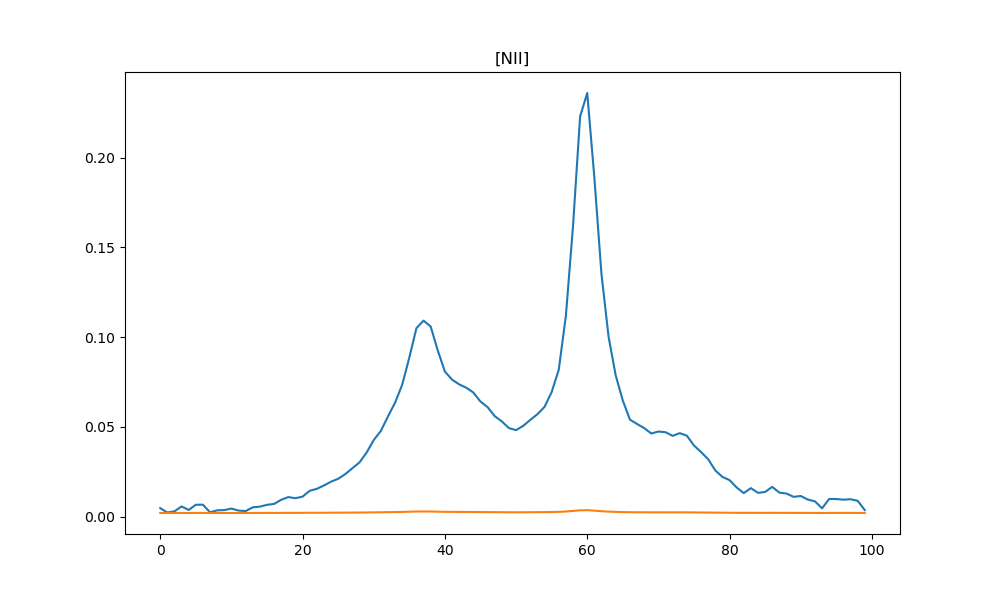

In [112]:
mask_NII = (wavelenghts > l_NII-10)*(wavelenghts < l_NII+10)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
weights_NII = 1/image_error_NII**2
radial_profile_NII, sum_weights_NII = np.average(image_NII, axis = 1, weights = weights_NII, returned = True)
radial_profile_error_NII = 1/np.sqrt(sum_weights_NII)
#radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))/image_error_NII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [113]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 5.126803081582061
differential_evolution step 2: f(x)= 1.1458950665099956
differential_evolution step 3: f(x)= 0.4043121439963755
differential_evolution step 4: f(x)= 0.1368961047829907
differential_evolution step 5: f(x)= 0.057304884719095985
differential_evolution step 6: f(x)= 0.057304884719095985
differential_evolution step 7: f(x)= 0.057304884719095985
differential_evolution step 8: f(x)= 0.057304884719095985
differential_evolution step 9: f(x)= 0.057304884719095985
differential_evolution step 10: f(x)= 0.057304884719095985
differential_evolution step 11: f(x)= 0.021044566386365992
differential_evolution step 12: f(x)= 0.021044566386365992
differential_evolution step 13: f(x)= 0.021044566386365992
differential_evolution step 14: f(x)= 0.021044566386365992
differential_evolution step 15: f(x)= 0.009936666550057214
differential_evolution step 16: f(x)= 0.009936666550057214
differential_evolution step 17: f(x)= 0.009936666550057214
differential_ev

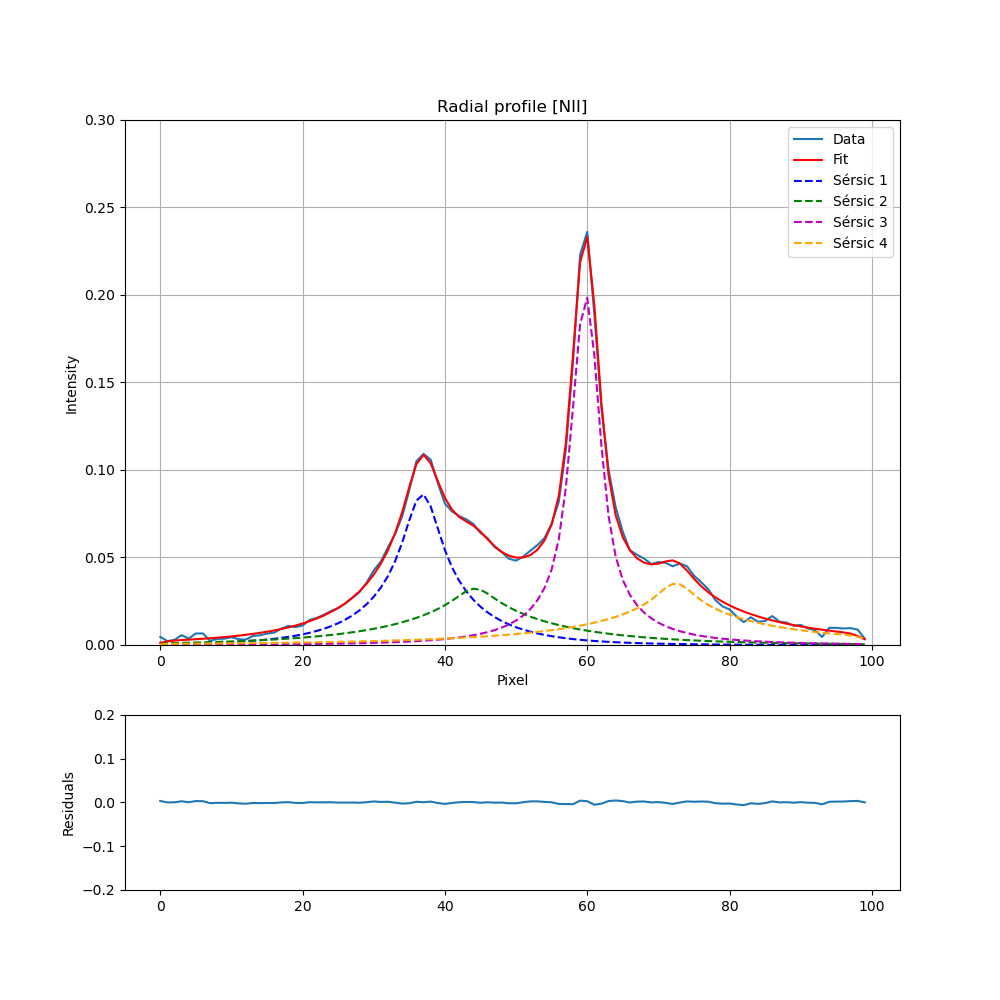

In [114]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 0.3)

ax[1].plot(x_axes, radial_profile_NII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_NII_kernel')

In [115]:
params_curve_NII, covariance_NII = curve_fit(model_convolved, x_axes, radial_profile_NII, p0=result.x, sigma = radial_profile_error_NII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_NII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_NII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_NII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("NII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_NII)))
#print(infodict.fvec**2)
chi2_NII = np.sum((((radial_profile_NII - model_convolved(x_axes, *params_curve_NII)) / radial_profile_error_NII)**2))
dof_NII = len(radial_profile_NII) - len(params_curve_NII)
chi2_reduced_NII = chi2_NII / dof_NII
print(chi2_reduced_NII)

Sérsic 1: I_e=0.0121, r_e=12.1798, n=1.3089, x_0=36.7943
Sérsic 2: I_e=0.0042, r_e=22.2710, n=1.2552, x_0=44.2242
Sérsic 3: I_e=0.0083, r_e=13.4991, n=2.4563, x_0=59.7614
Sérsic 4: I_e=0.0025, r_e=40.2367, n=1.6304, x_0=72.4766
[3.41701947e-03 3.98838331e+00 1.92390355e-01 1.20985906e-01
 2.53512785e-03 1.40174396e+01 3.12676250e-01 5.56546333e-01
 1.42162774e-02 1.76867671e+01 1.52845243e+00 2.00868141e-02
 1.41882623e-03 1.67705928e+01 3.14721292e-01 3.14242027e-01]
0.9617697229987827


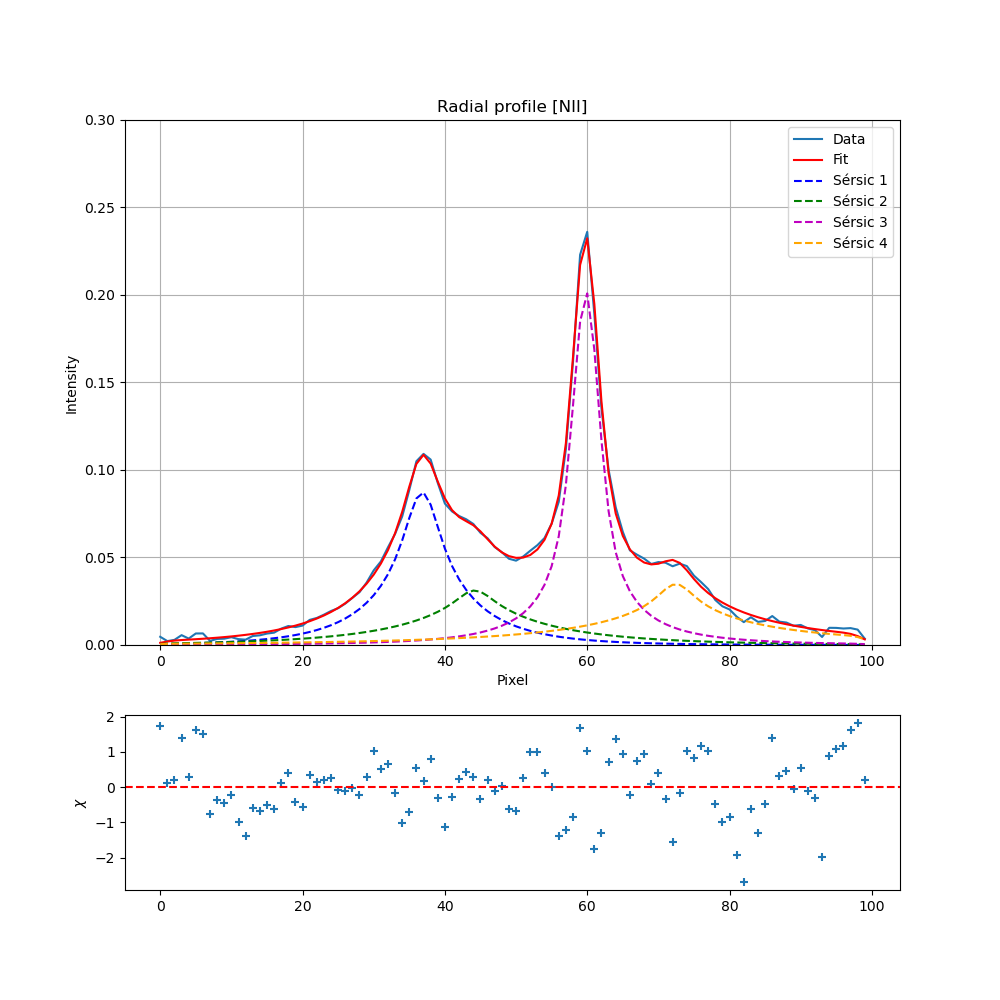

In [116]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_NII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_NII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_NII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [NII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 0.3)

ax[1].scatter(x_axes, (radial_profile_NII - y_fit)/radial_profile_error_NII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

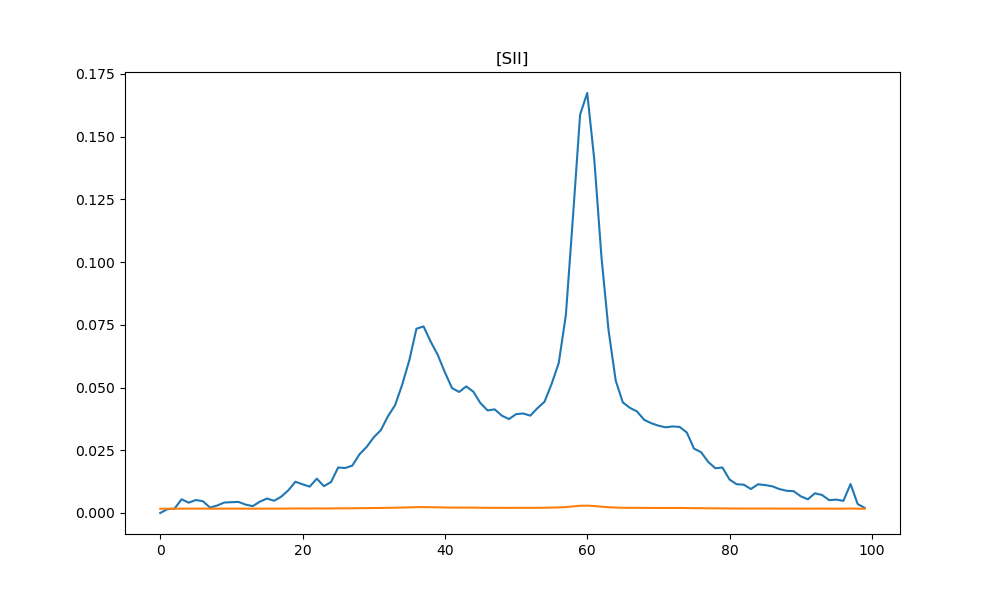

In [117]:
mask_SII = (wavelenghts > l_SII-10)*(wavelenghts < l_SII+10)
x_axes = np.arange(0, 100, 1)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
weights_SII = 1/image_error_SII**2
radial_profile_SII, sum_weights_SII = np.average(image_SII, axis = 1, weights = weights_SII, returned = True)
radial_profile_error_SII = 1/np.sqrt(sum_weights_SII)
#radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))/image_error_SII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [118]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2.8708106114443264
differential_evolution step 2: f(x)= 2.0753379742291984
differential_evolution step 3: f(x)= 0.07838757491157895
differential_evolution step 4: f(x)= 0.07838757491157895
differential_evolution step 5: f(x)= 0.07838757491157895
differential_evolution step 6: f(x)= 0.07838757491157895
differential_evolution step 7: f(x)= 0.07838757491157895
differential_evolution step 8: f(x)= 0.07838757491157895
differential_evolution step 9: f(x)= 0.07838757491157895
differential_evolution step 10: f(x)= 0.06131194293008022
differential_evolution step 11: f(x)= 0.045060431428542776
differential_evolution step 12: f(x)= 0.031734675589251
differential_evolution step 13: f(x)= 0.031734675589251
differential_evolution step 14: f(x)= 0.021977253315685893
differential_evolution step 15: f(x)= 0.021977253315685893
differential_evolution step 16: f(x)= 0.020934496786788832
differential_evolution step 17: f(x)= 0.020934496786788832
differential_evolution s

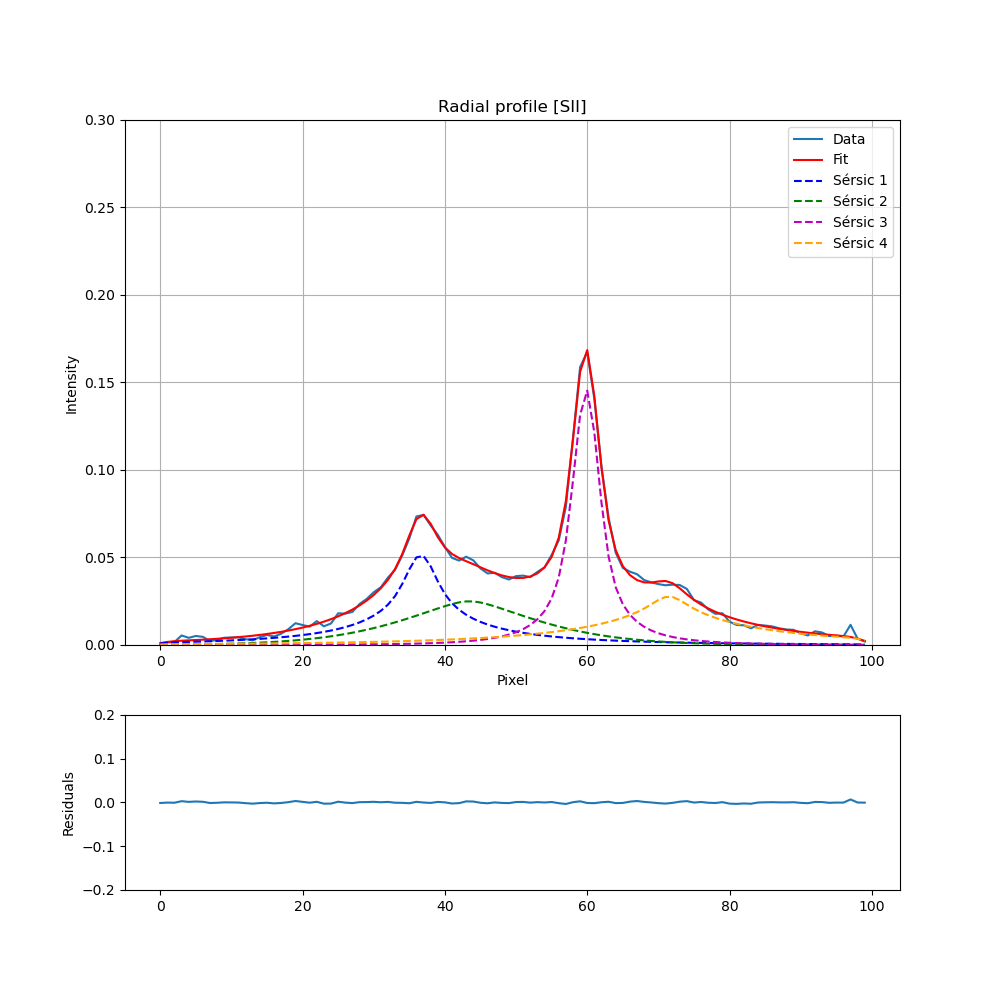

In [119]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0,0.3)

ax[1].plot(x_axes, radial_profile_SII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')
plt.savefig('Radial_profile_SII_diff')

In [120]:
params_curve_SII, covariance_SII = curve_fit(model_convolved, x_axes, radial_profile_SII, p0=result.x, sigma = radial_profile_error_SII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_SII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_SII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_SII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("SII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_SII)))
#print(infodict.fvec**2)
chi2_SII = np.sum((((radial_profile_SII - model_convolved(x_axes, *params_curve_SII)) / radial_profile_error_SII)**2))
dof_SII = len(radial_profile_SII) - len(params_curve_SII)
chi2_reduced_SII = chi2_SII / dof_SII
print(chi2_reduced_SII)

Sérsic 1: I_e=0.0025, r_e=27.6445, n=2.0068, x_0=36.5982
Sérsic 2: I_e=0.0088, r_e=13.8834, n=0.6844, x_0=43.0711
Sérsic 3: I_e=0.0079, r_e=9.8903, n=2.2960, x_0=59.8110
Sérsic 4: I_e=0.0023, r_e=36.7945, n=1.5255, x_0=71.6546
[3.19618345e-03 2.58273264e+01 7.76814871e-01 1.50326099e-01
 4.91590550e-03 4.46977692e+00 2.11339379e-01 2.55883945e+00
 1.82576567e-02 1.65534512e+01 2.28994121e+00 6.88933434e-03
 1.64451168e-03 1.79820701e+01 3.57681293e-01 3.78372543e-01]
0.907916183291696


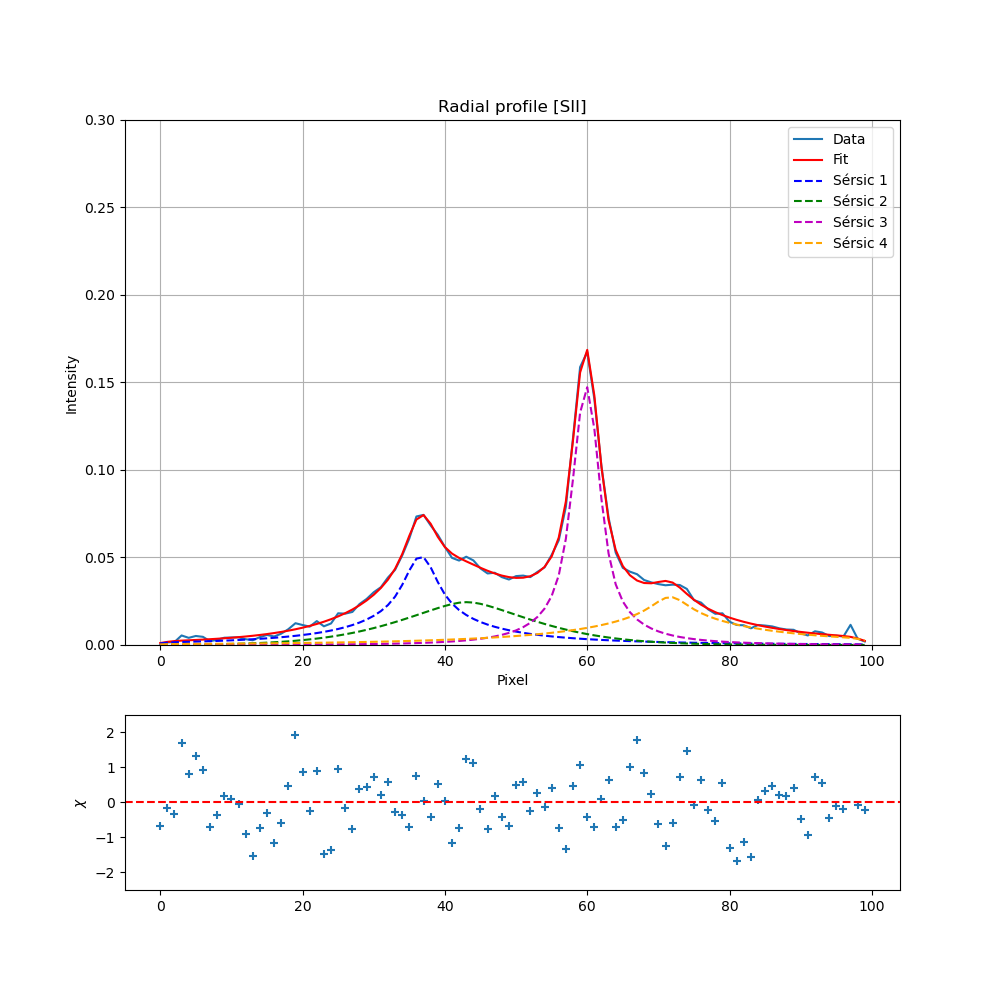

In [121]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_SII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_SII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_SII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [SII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 0.3)

ax[1].scatter(x_axes, (radial_profile_SII - y_fit)/radial_profile_error_SII,marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
ax[1].set_ylim(-2.5, 2.5)
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

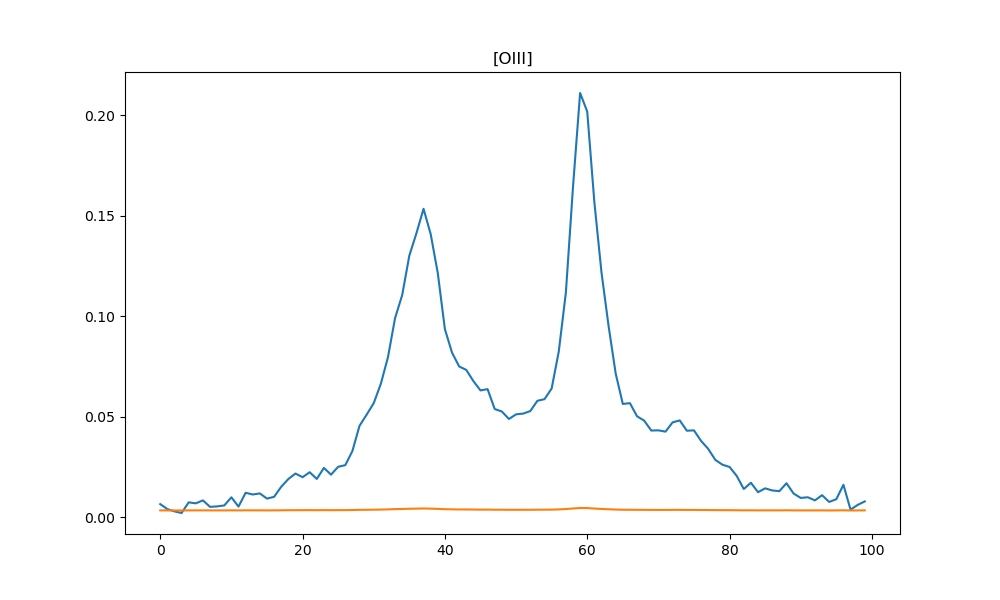

In [122]:
mask_OIII = (wavelenghts > l_OIII-10)*(wavelenghts < l_OIII+10)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
weights_OIII = 1/image_error_OIII**2
radial_profile_OIII, sum_weights_OIII = np.average(image_OIII, axis = 1, weights = weights_OIII, returned = True)
radial_profile_error_OIII = 1/np.sqrt(sum_weights_OIII)
#radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))/image_error_OIII.shape[1]
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [123]:
sigma = 3.125 / 2.35

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs):
    y_model = model_convolved(x, *params)
    return np.sum((y_obs - y_model)**2)

# Bounds:
bounds = [
    (0, 0.1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-1.5, x_0_HA[0]+1.5),   # x_0: circa la posizione di Halpha

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[1]-1.5, x_0_HA[1]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[2]-1.5, x_0_HA[2]+1.5),

    (0, 0.1),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-1.5, x_0_HA[3]+1.5)
]

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII)

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(4):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 0.22777846659944234
differential_evolution step 2: f(x)= 0.13977431402085497
differential_evolution step 3: f(x)= 0.07861659765114319
differential_evolution step 4: f(x)= 0.06756750234797083
differential_evolution step 5: f(x)= 0.06756750234797083
differential_evolution step 6: f(x)= 0.06756750234797083
differential_evolution step 7: f(x)= 0.06756750234797083
differential_evolution step 8: f(x)= 0.04019035414676357
differential_evolution step 9: f(x)= 0.04019035414676357
differential_evolution step 10: f(x)= 0.03321066934029183
differential_evolution step 11: f(x)= 0.029853232949057125
differential_evolution step 12: f(x)= 0.029853232949057125
differential_evolution step 13: f(x)= 0.027187461654991616
differential_evolution step 14: f(x)= 0.027187461654991616
differential_evolution step 15: f(x)= 0.01880865957306173
differential_evolution step 16: f(x)= 0.015418854601680215
differential_evolution step 17: f(x)= 0.015418854601680215
differential_evol

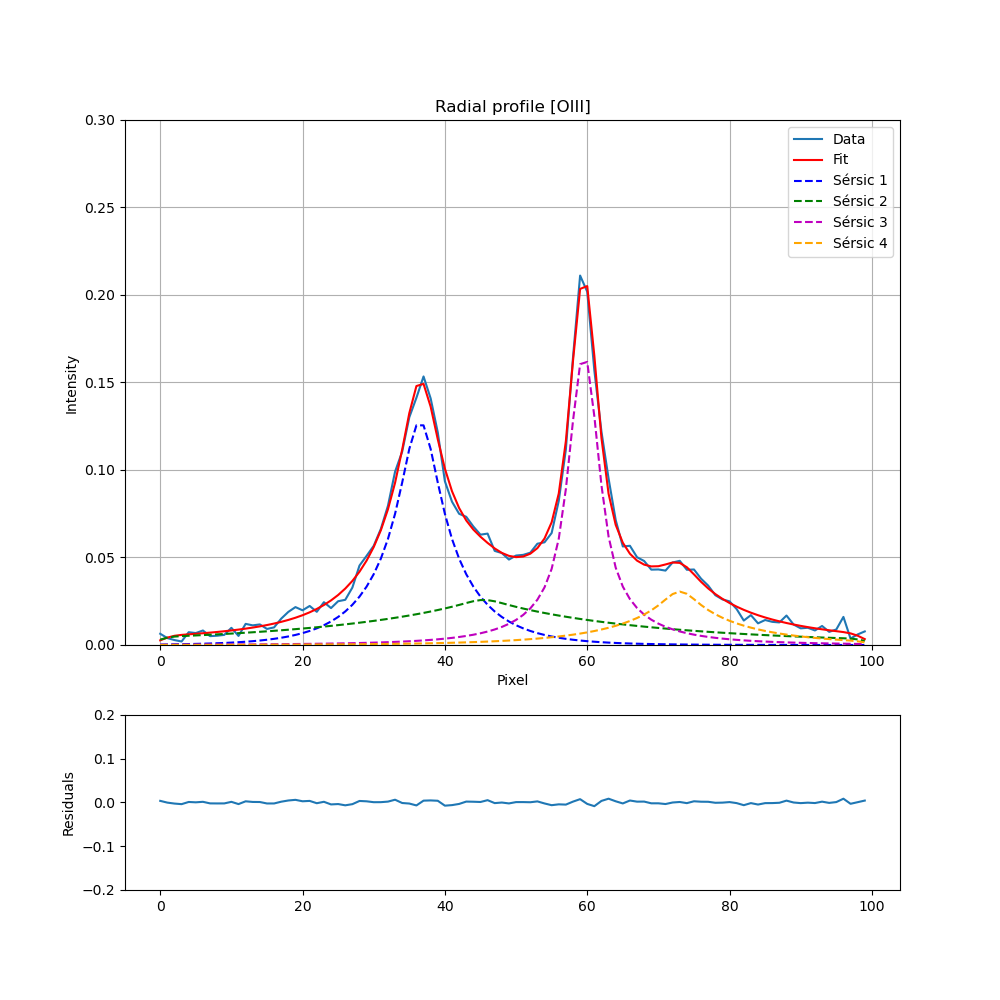

In [124]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *best_params)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *best_params[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 0.3)

ax[1].plot(x_axes, radial_profile_OIII - y_fit)
ax[1].set_ylim(-0.2, 0.2)
ax[1].set_ylabel('Residuals')

plt.savefig('Radial_profile_OIII_kernel')

In [125]:
params_curve_OIII, covariance_OIII = curve_fit(model_convolved, x_axes, radial_profile_OIII, p0=result.x, sigma = radial_profile_error_OIII)

I_e = np.zeros(4)
r_e = np.zeros(4)
n = np.zeros(4)
x_0 = np.zeros(4)

I_e_err = np.zeros(4)
r_e_err = np.zeros(4)
n_err = np.zeros(4)
x_0_err = np.zeros(4)

for i in range(4):
    I_e[i], r_e[i], n[i], x_0[i] = params_curve_OIII[i*4:(i+1)*4]
    I_e_err[i] = np.sqrt(np.diag(covariance_OIII)[i*4])
    r_e_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+1])
    n_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+2])
    x_0_err[i] = np.sqrt(np.diag(covariance_OIII)[(i*4)+3])
    print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

d1 = {'Component': [1, 2, 3, 4], 'I_e': I_e , 'I_e error': I_e_err, 'r_e': r_e, 'r_e error': r_e_err, 'n': n, 'n error': n_err, 'x_0': x_0, 'x_0 err': x_0_err}
df1 = pd.DataFrame(data=d1)
df1.to_csv("OIII_fit.csv", index= False, float_format='%.4f')

#print(covariance)
print(np.sqrt(np.diag(covariance_OIII)))
#print(infodict.fvec**2)
chi2_OIII = np.sum((((radial_profile_OIII - model_convolved(x_axes, *params_curve_OIII)) / radial_profile_error_OIII)**2))
dof_OIII = len(radial_profile_OIII) - len(params_curve_OIII)
chi2_reduced_OIII = chi2_OIII / dof_OIII
print(chi2_reduced_OIII)

Sérsic 1: I_e=0.0224, r_e=9.5067, n=1.1838, x_0=36.4832
Sérsic 2: I_e=0.0030, r_e=62.4147, n=1.2867, x_0=45.5559
Sérsic 3: I_e=0.0074, r_e=14.1214, n=2.4203, x_0=59.5386
Sérsic 4: I_e=0.0042, r_e=17.1179, n=1.2580, x_0=73.1745
[4.14852240e-03 2.25099649e+00 1.36001985e-01 1.03832944e-01
 6.01171119e-03 8.36681808e+01 8.68630891e-01 1.81814083e+00
 2.71978197e-02 3.99517536e+01 3.26860461e+00 1.32078994e-02
 2.29476557e-03 1.15186350e+01 3.50894842e-01 5.46175334e-01]
1.024433019291042


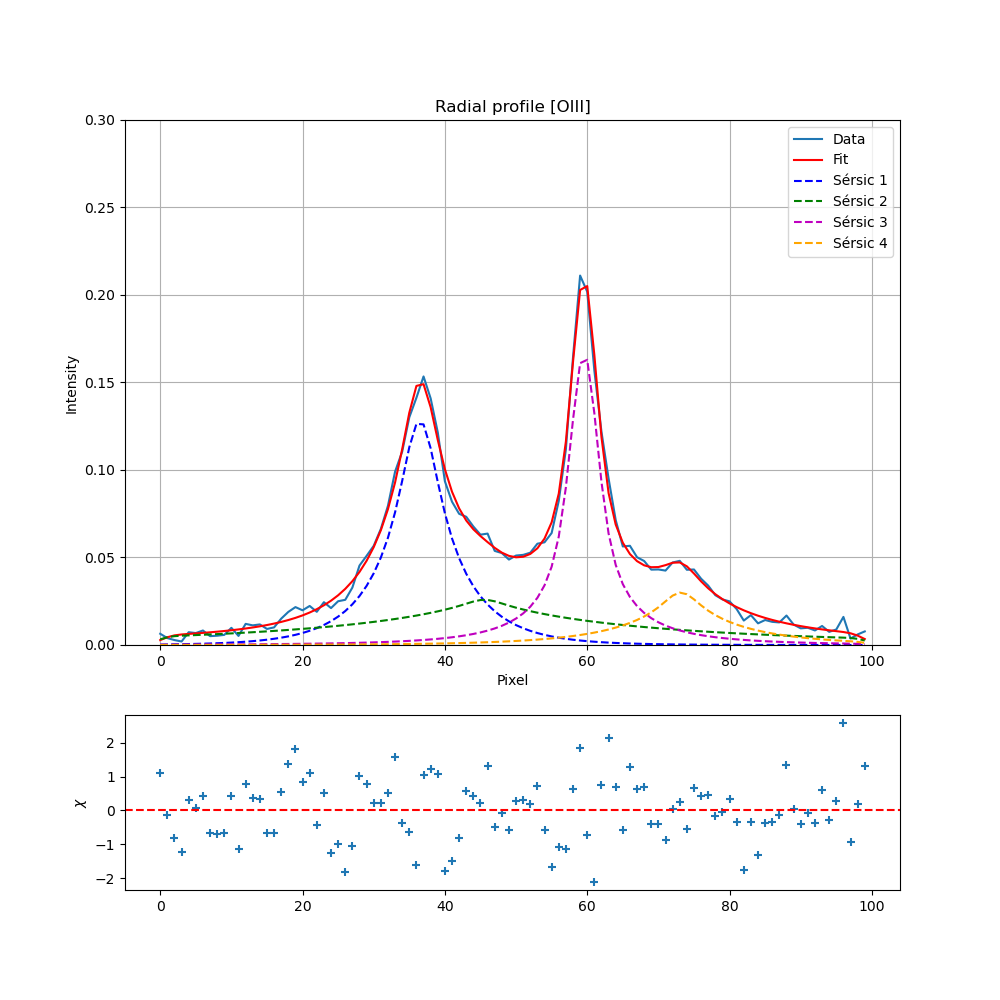

In [126]:
# Plots:
xgrid = np.linspace(min(x_axes), max(x_axes), 100)
y_fit = model_convolved(xgrid, *params_curve_OIII)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

def sersic_1d_convolved(x, I_e, r_e, n, x_0):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

ax[0].plot(x_axes, radial_profile_OIII, label='Data')
ax[0].plot(xgrid, y_fit, 'r-', label='Fit')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[0:4]), 'b--', label='Sérsic 1')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[4:8]), 'g--', label='Sérsic 2')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[8:12]), 'm--', label='Sérsic 3')
ax[0].plot(xgrid, sersic_1d_convolved(xgrid, *params_curve_OIII[12:16]), color='orange', linestyle='--', label='Sérsic 4')

ax[0].set_xlabel("Pixel")
ax[0].set_ylabel("Intensity")
ax[0].set_title("Radial profile [OIII]")
ax[0].legend()
ax[0].grid(True)
ax[0].set_ylim(0, 0.3)

ax[1].scatter(x_axes, (radial_profile_OIII - y_fit)/radial_profile_error_OIII, marker = '+')
ax[1].axhline(0, color ='red', linestyle ='dashed')
ax[1].set_ylabel(r'$\chi$')
plt.savefig('Radial_profile_OIII_curve')

In [127]:
radial_profile_OIII - y_fit

array([ 0.00361639, -0.00047589, -0.00267753, -0.00400883,  0.00097783,
        0.0002014 ,  0.00137268, -0.00218659, -0.00230201, -0.00222533,
        0.00138616, -0.00371685,  0.00263868,  0.00120488,  0.0010821 ,
       -0.00223683, -0.00218009,  0.00186894,  0.00464993,  0.00615974,
        0.00291332,  0.00374984, -0.00150557,  0.00176078, -0.00422526,
       -0.00339748, -0.00626743, -0.00364726,  0.00364791,  0.00281265,
        0.00075363,  0.00076697,  0.00195488,  0.00617251, -0.00141745,
       -0.00262972, -0.00676398,  0.00440751,  0.00508007,  0.00433087,
       -0.00690499, -0.00570231, -0.00309495,  0.00212604,  0.00158634,
        0.0007931 ,  0.00486837, -0.00174961, -0.00023379, -0.00210864,
        0.00100978,  0.00107377,  0.00070892,  0.0026072 , -0.00213939,
       -0.00611685, -0.00411745, -0.00445242,  0.00269701,  0.00824204,
       -0.00321454, -0.0088954 ,  0.00304673,  0.00829187,  0.00258305,
       -0.00213106,  0.0047096 ,  0.00224774,  0.00247589, -0.00

In [128]:
radial_profile_error_OIII

array([0.00330911, 0.00328945, 0.00327956, 0.00327618, 0.00331007,
       0.00331309, 0.00332452, 0.00330453, 0.00330596, 0.00330261,
       0.00333186, 0.00330405, 0.00334463, 0.00332988, 0.00333328,
       0.00331439, 0.0033341 , 0.00335868, 0.00338943, 0.0034127 ,
       0.00341862, 0.00343621, 0.00340848, 0.0034439 , 0.00341152,
       0.00343602, 0.0034449 , 0.00348681, 0.00358001, 0.00361474,
       0.00365604, 0.00372154, 0.00380736, 0.00394749, 0.00400422,
       0.00412846, 0.00418457, 0.00425562, 0.00417999, 0.00406188,
       0.00389972, 0.00383074, 0.00377935, 0.00376762, 0.00373123,
       0.00368511, 0.00369717, 0.00363412, 0.00364231, 0.00360527,
       0.00361231, 0.00361666, 0.00362131, 0.0036564 , 0.00365489,
       0.00368827, 0.00380245, 0.00397233, 0.00426444, 0.0045076 ,
       0.00446802, 0.00421915, 0.00403195, 0.0038729 , 0.00372291,
       0.00363374, 0.00363416, 0.00359426, 0.00357755, 0.00353948,
       0.00354108, 0.00353852, 0.00357236, 0.00357452, 0.00353